<a href="https://colab.research.google.com/github/AmirAsgary/Teaching/blob/main/MachineLearning_MolBio_2025%20/Tutorial/Tutorial_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning - Practical 2 - Multiclass Logistic Regression



  

## In this practical we will implement multiclass classification with classic Logistic Regression

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.utils import Bunch


# The Dataset

## The dataset consists of gene expression of a set of genes and a label for which cell type they belong to. From the gene expression, we want to learn how to predict which cell type they belong to.


In [ ]:
# Load the data
data = pd.read_csv('celltype_gene_expression_mixed.csv')
print(data.shape)

label_to_cell = {0: 'Cell type A',
                1: 'Cell type B',
                2: 'Cell type C',
                3: 'Cell type D'}

data.head()

## **Task 1:**

## Split the data into training (80%) and test (20%) set. Note: most machine learning algorithms require numerical input labels rather than categorical string labels- therefore we assign intergers to the cell type classes.

## STRATIFY SPLITTING-  to ensure that the proportion of each cell type (class) is preserved in both training and testing sets. This avoids data leakage and ensures the test set is representative of the class distribution.

In [ ]:
# Extract features matrix X (all gene expression columns)
# Hint: Save all columns except 'Cell_Type' under a variable 'X' which should be a matrix.
# ---- insert your code here ---- #



# Create a vector that would store the labels of cell type column. Then, convert each label to a unique integer value.
# This is called the label vector 'y'.
# ---- insert your code here ---- #


In [ ]:
# import train_test_split function from sklearn
# Split into train and test sets (80% train, 20% test), fixed random state for reproducibility
# ---- insert your code here ---- #



# ---- insert your code here ---- #

In [ ]:
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("Training labels shape:", y_train.shape)
print("Test labels shape:", y_test.shape)


## **Task 2:**

## Data visualization and normalization

## From tutorial 1 you have learnt how to visualize your data and normalize it. You can refer to the code you have written earlier for the following questions.



* First sort and select the 3 genes with the highest variances in their expression

*  Histogram: plot a histogram for all of the genes in a 2*5 grid. You can use AI.

*   Log10 transform your 10 genes and plot histogram of your normalized features in a 2*5 grid.

*   Standardize your log transformed data `(x-mean)/var` and plot boxplots for each gene to view their distribution after standardization













In [ ]:
# Calculate variance of each gene expression column

# Get indices of top 3 genes sorted by variance in descending order

# Print the top 3 genes and their variances


In [ ]:
# Plot a 2*5 histogram of all features (genes) across all cell types before the transformation/standardization


In [ ]:
# Log transform your data


# Calculate the mean and variance of each gene in your training data.
# Hint --> make sure to use the correct axis to take the mean and var OVER THE GENES!


# Standardize both train and test using training parameters (Mean and Var)


# Plot a 2*5 histogram of all features (genes) across all cell types after the standardization on training data!



In [ ]:
print("Training set shape:", X_standardized_train.shape)
print("Test set shape:", X_standardized_test.shape)

# Logistic Regression

## Logistic Regression is a statistical method used for binary or multi-class classification tasks. Unlike linear regression, which predicts continuous outcomes, logistic regression predicts the probability that a given observation belongs to a particular class.

## The model uses the logistic (sigmoid) function to map any real-valued input to a range between 0 and 1. The general form of the model is:

$$
\hat{y_i} = \sigma\left(w_0 + w_1 x_{i1} + w_2 x_{i2} + \dots + w_n x_{in}\right) = \frac{1}{1 + e^{-\left(w_0 + w_1 x_{i1} + \dots + w_n x_{in}\right)}}
$$

## where $\hat{y_i}$ is the predicted probability that observation $i$ belongs to the positive class, $w_0$ is the intercept, $w_1, w_2, \dots, w_n$ are weights corresponding to each feature $x_1, x_2, \dots, x_n$, and $\sigma(\cdot)$ is the sigmoid function which ensures outputs lie between 0 and 1.

## The coefficients $w$ are estimated by minimizing the log-loss (cross-entropy loss):

$$
L(w) = - \sum_{i=1}^m \left[ y_i \log(\hat{y_i}) + (1 - y_i) \log(1 - \hat{y_i}) \right]
$$
## Where $m$ is the total number of samples in your data.

## In other words, logistic regression seeks the best set of weights $w$ that make the predicted probabilities $\hat{y_i}$ as close as possible to the actual class labels $y_i$.

---

# Multiclass Logistic Regression (Softmax Regression)

## When we have more than two classes, logistic regression is extended using the **softmax function**. Instead of a single sigmoid output, the model produces one score for each class, and the softmax function converts these scores into probabilities that sum to 1.

## For an input vector $\mathbf{x_i}$, the model computes:

$$
z_j = w_{j0} + w_{j1}x_{i1} + w_{j2}x_{i2} + \dots + w_{jn}x_{in}
$$

## for each class \( $j = 1, 2, \dots, K \$), where \( K \) is the total number of classes.

## The **softmax function** then converts these scores into probabilities:

$$
P(y_i = j \mid \mathbf{x_i}) = \frac{e^{z_j}}{\sum_{k=1}^{K} e^{z_k}}
$$

## This ensures that all predicted probabilities are positive and sum to one:

$$
\sum_{j=1}^{K} P(y_i = j \mid \mathbf{x_i}) = 1
$$

## The loss function for multiclass logistic regression is a generalization of binary cross-entropy, called **categorical cross-entropy**:

$$
L(w) = - \sum_{i=1}^m \sum_{j=1}^K y_{ij} \log P(y_i = j \mid \mathbf{x_i})
$$

## Where $m$ is the total number of samples and $K$ is the total number of classes. Here, $y_{ij} = 1$ if sample $i$ belongs to class $j$, otherwise $0$ .  

## In simple terms, **softmax regression** finds the set of weights that make the model’s predicted class probabilities match the true classes as closely as possible.


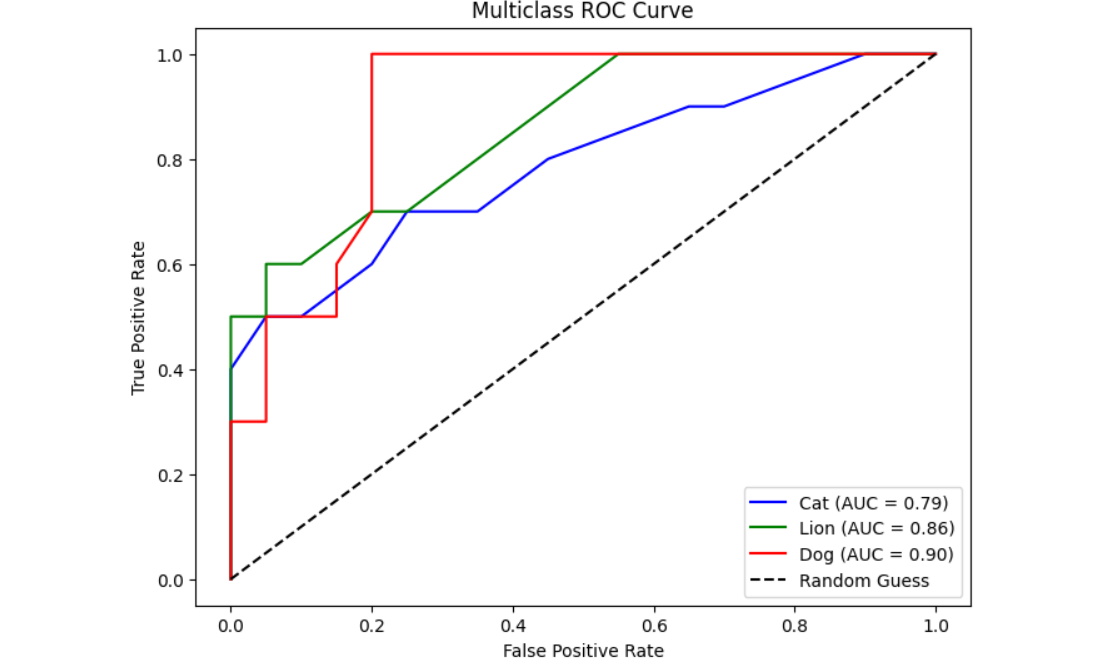

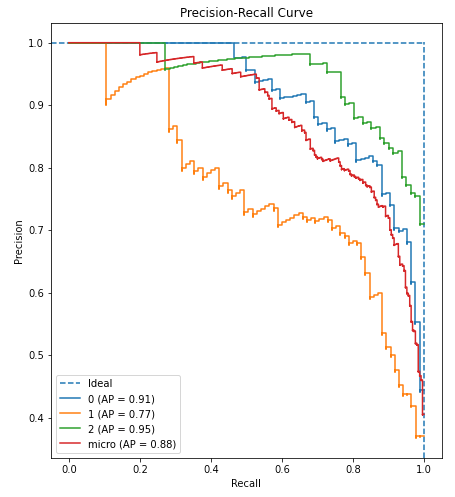

## Understanding the Confusion Matrix

A **confusion matrix** is a simple and powerful way to evaluate how well a classification model performs.  
It shows the number of correct and incorrect predictions made by the model, broken down by each class.

---

For a classification problem with multiple classes, the confusion matrix is a square table:

| **True \ Predicted** | **Class 1** | **Class 2** | **Class 3** | ... |
|----------------------:|:------------:|:------------:|:------------:|:--:|
| **Class 1** (Actual) |  ✅ Correct  | ❌ Wrong     | ❌ Wrong     | ... |
| **Class 2** (Actual) | ❌ Wrong     | ✅ Correct   | ❌ Wrong     | ... |
| **Class 3** (Actual) | ❌ Wrong     | ❌ Wrong     | ✅ Correct   | ... |
| ...                  | ...          | ...          | ...          | ... |

- Each **row** represents the **true class** (the actual label).
- Each **column** represents the **predicted class** (the label the model predicted).

---

### How to Interpret It

- **Diagonal elements (top-left → bottom-right):**  
  These show how many samples were correctly classified for each class.  
  The higher these numbers, the better the model performs.

- **Off-diagonal elements:**  
  These show where the model made mistakes — it predicted the wrong class.

---
### Key Metrics Derived from the Matrix

From the confusion matrix, we can calculate:
- **Accuracy** – overall correctness of predictions  
- **Precision** – how many predicted positives are actually correct  
- **Recall (Sensitivity)** – how many true positives the model successfully found  
- **F1-score** – balance between precision and recall



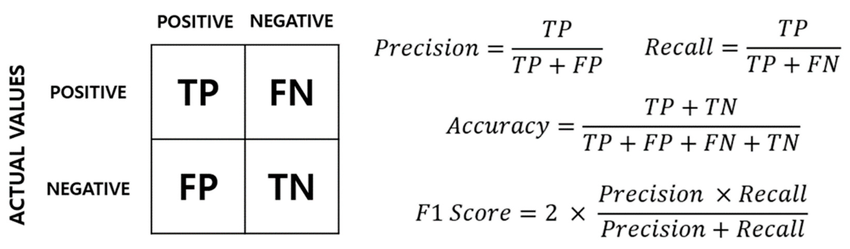

---
---
## **Task 3:** Use sklearn to fit a multiclass logistic regression model

## Now, familiarize yourself with the sklearn library. This is the section on logistic regression : https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html



## You will find `sklearn.linear_model.LogisticRegression`, the sklearn implementation of logistic regression. Use this sklearn class to implement logistic regression. Obtain estimates of the weights on `X_standardized_train` and `y_train` and compute performance metrics such as accuracy and weighted F1-score on `X_standardized_test` and `y_test`.

## Calculate the ROC AUC and plot its curve for all classes.

## Additionally, calculate and plot Precision-Recall (PR) curves for each class, which is particularly useful for imbalanced datasets or multi-class classification.

## Steps to follow for evaluation of the model:

## - Train logistic regression on the standardized training data using `clf.fit(X_standardized_train, y_train)`.
## - Predict class labels and probabilities on the test data using `clf.predict(X_standardized_test)` and `clf.predict_proba(X_standardized_test)`.
## - Calculate accuracy and weighted F1 score with `accuracy_score` and `f1_score`.
## - Binarize the test labels using `label_binarize` for multi-class PR curve plotting (1)
## - Plot precision-recall curves for each class with `precision_recall_curve` and compute area under the curve (AUC) using `auc`.
## - Visualize PR curves with `matplotlib.pyplot`.

## This approach gives a comprehensive evaluation of logistic regression beyond simple accuracy metrics.


## In multi-class classification, each test sample belongs to one of several classes. However, some evaluation metrics, including precision-recall (PR) curves, require the labels to be in a binary indicator format for each class, rather than a single integer class label.The `label_binarize` function from `sklearn.preprocessing` converts the vector of integer class labels into a binary matrix, where each row corresponds to a test sample,and each column corresponds to a class.


## To make the life easier, we wrote a function to plot Percision Recall (PR) and ROC curve

In [ ]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, confusion_matrix

def plot_multiclass_roc_pr(y_test_bin, y_prob, label_to_cell):
    """
    Plot ROC, Precision-Recall curves, and Confusion Matrix for multiclass classification.

    Parameters
    ----------
    y_test_bin : np.ndarray
        Binary matrix of true labels, shape (n_samples, n_classes).
    y_prob : np.ndarray
        Predicted probabilities, shape (n_samples, n_classes).
    label_to_cell : dict or list
        Mapping from class index to label name.
    """
    n_classes = y_test_bin.shape[1]

    plt.figure(figsize=(10, 16))

    # --- ROC Curve ---
    plt.subplot(3, 1, 1)
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{label_to_cell[i]} (AUC={roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.grid(True)

    # --- Precision-Recall Curve ---
    plt.subplot(3, 1, 2)
    for i in range(n_classes):
        precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_prob[:, i])
        pr_auc = auc(recall, precision)
        plt.plot(recall, precision, label=f'{label_to_cell[i]} (AUC={pr_auc:.2f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend()
    plt.grid(True)

    # --- Confusion Matrix ---
    y_true = np.argmax(y_test_bin, axis=1)
    y_pred = np.argmax(y_prob, axis=1)
    cm = confusion_matrix(y_true, y_pred)

    plt.subplot(3, 1, 3)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[label_to_cell[i] for i in range(n_classes)],
                yticklabels=[label_to_cell[i] for i in range(n_classes)])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')

    plt.tight_layout()
    plt.show()


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_recall_curve, roc_curve, auc
from sklearn.preprocessing import label_binarize

# Define your logistic regression model and call it 'clf'

# Fit your model on `X_standardized_train`

# After training, you need to predict on X_standardized_test. It will give you the probabilities (y_pred)
# You can use clf.predict_proba to get the probabilities
# Convert your probabilities to the most likely target label (argmax).


# Calculate and report your accuracy and f1-score on test set


# binarize your test data (y_test) with label_binarize function.
# Array of dim (num_samples,) [0,...] --> Array of dim (num_samples, num_classes) [[1,0,0,0],...]


Now visualize your data with the following cell.

In [ ]:
# Plot ROC curve and PR curve
# y_test_bin --> binarized y_test
# y_prob --> predicted probabilities for test set
# label_to_cell --> fixed variable, no need to change!
plot_multiclass_roc_pr(y_test_bin, y_prob, label_to_cell)


What do you see? How informative do you think the test accuracy and F1 score and PR curves are- is one more informative than the others?

Hint- think of how an unbalanced dataset can affect these scores?

Is your model performing well for ALL the classes? If not, why?


## **Task 4:**

## To find out if this dataset is imbalanced we would need to check how many samples are present in each cell type and visualise the distributions of each cell types by plotting a per-cell type histogram of each cell type in the same plot.

## we have provided you with the code to do this below.

## When you run the code, what do you see? Are there equal number of each cell types samples? Are the distributions of the cell types very different from each other, or do they overlap?


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate sample size per cell type
celltype_size = data['Cell_Type'].value_counts()
print("Sample size per Cell_Type:")
print(celltype_size)

Based on the class numbers, define the class weights for each cell type below and run the training and evaluation (only PR curve) again.


To mitigate the class inbalance, we can apply something known as class weighting, assigning higher weights to smaller classes so that the model gives them proportional influence during training.

## Weighted Multiclass Cross-Entropy Loss

When some classes appear more often than others, the model might become biased toward the majority classes.  
To handle this imbalance, we can assign a **class weight** \( w_j \) to each class \( j \), giving more importance to underrepresented classes.

The **weighted loss function** becomes:

$$
L(w) = - \sum_{i=1}^m \sum_{j=1}^K w_j \, y_{ij} \log P(y_i = j \mid \mathbf{x_i})
$$
Where:
- $m$: number of samples  
- $K$: number of classes  
- $y_{ij}$: indicator (1 if sample $i$ belongs to class $j$, otherwise 0  
- $P(y_i = j \mid \mathbf{x_i})$: predicted probability that sample \( i \) belongs to class \( j \)  
- $w_j$: **class weight** — a scaling factor that increases or decreases the loss contribution of class $j$

In [ ]:
# change the weights bellow
weights = {
    cell_to_label["Cell type A"]: 1, # insert your class weight
    cell_to_label["Cell type B"]: 1, # insert your class weight
    cell_to_label["Cell type C"]: 1, # insert your class weight
    cell_to_label["Cell type D"]: 1, # insert your class weight
}

If you have change your weights, run the next cell and compare the performance of your model with different weights.


In [ ]:
clf = LogisticRegression(max_iter=1000, class_weight=weights)
clf.fit(X_standardized_train, y_train)
y_prob = clf.predict_proba(X_standardized_test)
y_pred = np.argmax(y_prob, axis=1)
y_test_bin = label_binarize(y_test, classes=list(cell_to_label.values()))
plot_multiclass_roc_pr(y_test_bin, y_prob, label_to_cell)

Which weights give you the maximum performance and how did you define them?